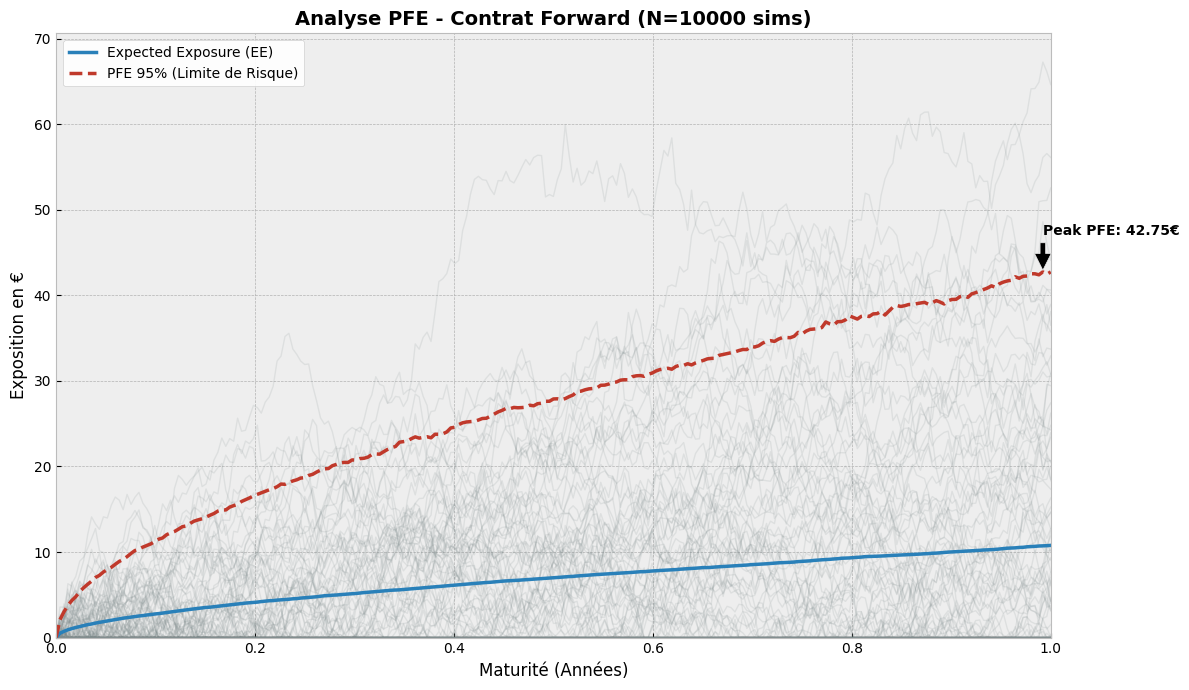

----------------------------------------
RAPPORT DE RISQUE SYNTHÉTIQUE
----------------------------------------
Produit      : Forward (Achat Action)
Spot Initial : 100 €
Strike       : 100 €
Volatilité   : 20.0 %
----------------------------------------
PFE Max (95%): 42.75 €
EE Moyenne   : 6.66 €
----------------------------------------


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Configuration "Pro" ---
# On utilise un style graphique épuré (Business/Finance style)
plt.style.use('bmh') 

def run_professional_pfe(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, n_sims=5000):
    """
    Simule et affiche le profil de risque de contrepartie (PFE) 
    pour un contrat Forward.
    
    Returns:
        None (Affiche le graphique et le rapport)
    """
    
    # --- 1. Paramétrage Temporel ---
    n_steps = 252  # Jours de trading (Standard annuel)
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1) # Axe des temps
    
    # --- 2. Moteur de Simulation (Vectorisé & Optimisé) ---
    # Génération de tous les chocs aléatoires en une seule fois (Matrice)
    # Shape: (5000 simulations, 252 jours)
    Z = np.random.normal(0, 1, (n_sims, n_steps))
    
    # Matrice des prix
    S = np.zeros((n_sims, n_steps + 1))
    S[:, 0] = S0
    
    # Boucle temporelle (Seulement sur les jours, pas les sims)
    for i in range(1, n_steps + 1):
        # Mouvement Brownien Géométrique
        drift = (r - 0.5 * sigma**2) * dt
        shock = sigma * np.sqrt(dt) * Z[:, i-1]
        S[:, i] = S[:, i-1] * np.exp(drift + shock)
        
    # --- 3. Calcul des Métriques de Risque (Risk Engine) ---
    # Mark-to-Market (MtM) du contrat Forward
    MtM = S - K
    
    # Exposition (On ne considère que les valeurs positives)
    Exposure = np.maximum(MtM, 0)
    
    # Agrégation statistique
    EE = np.mean(Exposure, axis=0)              # Expected Exposure (Moyenne)
    PFE = np.percentile(Exposure, 95, axis=0)   # PFE 95% (Scénario de stress)
    
    # --- 4. Visualisation Professionnelle ---
    plt.figure(figsize=(12, 7))
    
    # A. Fond: Trajectoires individuelles (Monte Carlo)
    # On n'en affiche que 100 pour ne pas saturer le graphique, avec transparence
    plt.plot(t, Exposure[:100, :].T, color='#7f8c8d', alpha=0.15, linewidth=1)
    
    # B. Courbes Principales
    plt.plot(t, EE, color='#2980b9', linewidth=2.5, label='Expected Exposure (EE)')
    plt.plot(t, PFE, color='#c0392b', linewidth=2.5, linestyle='--', label='PFE 95% (Limite de Risque)')
    
    # C. Mise en forme
    plt.title(f"Analyse PFE - Contrat Forward (N={n_sims} sims)", fontsize=14, fontweight='bold')
    plt.xlabel("Maturité (Années)")
    plt.ylabel("Exposition en €")
    plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    plt.xlim(0, T)
    plt.ylim(bottom=0)
    
    # Ajout d'une annotation pour le Pic de PFE
    max_pfe_idx = np.argmax(PFE)
    max_pfe_val = PFE[max_pfe_idx]
    max_pfe_time = t[max_pfe_idx]
    
    plt.annotate(f'Peak PFE: {max_pfe_val:.2f}€', 
                 xy=(max_pfe_time, max_pfe_val), 
                 xytext=(max_pfe_time, max_pfe_val*1.1),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 5. Rapport Textuel (Output Console) ---
    print("-" * 40)
    print(f"RAPPORT DE RISQUE SYNTHÉTIQUE")
    print("-" * 40)
    print(f"Produit      : Forward (Achat Action)")
    print(f"Spot Initial : {S0} €")
    print(f"Strike       : {K} €")
    print(f"Volatilité   : {sigma*100} %")
    print("-" * 40)
    print(f"PFE Max (95%): {np.max(PFE):.2f} €")
    print(f"EE Moyenne   : {np.mean(EE):.2f} €")
    print("-" * 40)

# --- Exécution du Script ---
# Tu peux changer tes paramètres ici directement
run_professional_pfe(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, n_sims=10000)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- 1. La Fonction Moteur (Tout le code précédent emballé) ---
def run_pfe_engine(S0, K, T, r, sigma, n_sims):
    """
    Cette fonction recalcule tout et refait le graphique
    à chaque fois qu'on bouge un curseur.
    """
    # Configuration
    n_steps = 252
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    
    # Simulation (Vectorisée)
    S = np.zeros((n_sims, n_steps + 1))
    S[:, 0] = S0
    
    for i in range(1, n_steps + 1):
        Z = np.random.normal(0, 1, n_sims)
        drift = (r - 0.5 * sigma**2) * dt
        shock = sigma * np.sqrt(dt) * Z
        S[:, i] = S[:, i-1] * np.exp(drift + shock)
    
    # Calcul PFE
    MtM = S - K
    E = np.maximum(MtM, 0) # Exposition
    
    EE = np.mean(E, axis=0)           # Moyenne (Bleu)
    PFE = np.percentile(E, 95, axis=0) # Risque 95% (Rouge)
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    
    # On limite l'affichage des simulation grises à 100 pour la lisibilité
    plt.plot(t, E[:100, :].T, color='grey', alpha=0.1)
    
    plt.plot(t, EE, color='blue', linewidth=2, label='Expected Exposure (EE)')
    plt.plot(t, PFE, color='red', linewidth=3, linestyle='--', label='PFE 95% (Risk Limit)')
    
    plt.title(f"PFE Viewer | Volatilité: {sigma*100}% | Simulations: {n_sims}")
    plt.xlabel("Temps (Années)")
    plt.ylabel("Exposition (€)")
    plt.ylim(bottom=0) # On fixe le bas à 0 pour voir l'effet du 'maximum'
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 2. Le Tableau de Bord (Les Widgets) ---

# Création des curseurs
ui = widgets.interactive(
    run_pfe_engine,
    S0 = widgets.IntSlider(min=50, max=150, step=5, value=100, description='Prix Spot'),
    K = widgets.IntSlider(min=50, max=150, step=5, value=100, description='Strike'),
    T = widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='Maturité'),
    r = widgets.FloatSlider(min=0.0, max=0.2, step=0.01, value=0.05, description='Taux (r)'),
    sigma = widgets.FloatSlider(min=0.05, max=0.8, step=0.05, value=0.2, description='Volatilité'),
    n_sims = widgets.IntSlider(min=100, max=5000, step=100, value=1000, description='Sims')
)

# Affichage
print(">>> PFE VIEWER READY <<<")
display(ui)

>>> PFE VIEWER READY <<<


interactive(children=(IntSlider(value=100, description='Prix Spot', max=150, min=50, step=5), IntSlider(value=…